---
title: "OMATA: floutage des visages"
author: "Anthony Hauser, Unisanté"
date: today
format:
  html:
    css: styles.css
    toc: true
    toc-location: left
    number-sections: true
    toc-depth: 4
    self-contained: true
    echo: false
page-layout: full
---

# Objectif

Anonymiser les images collectées en **floutant les visages**, entièrement **en local**
(aucune image n'est envoyée vers un service externe).

La détection des visages utilise **YuNet** (modèle ONNX léger, exécuté via le module
`cv2.FaceDetectorYN` d'OpenCV). Un flou gaussien est ensuite appliqué sur chaque
visage détecté.

Les fonctions réutilisables sont regroupées dans la bibliothèque `src/blur_utils.py`
(qui propose aussi un détecteur alternatif, CenterFace). Les images floutées sont
sauvegardées dans `results/blurred_images/yunet/`.

> Dépendances supplémentaires : `opencv-python`, `numpy`.
> Installation : `pip install opencv-python numpy`

In [6]:
#| include: false
# ===== Imports =====
# load libraries if needed: %pip install opencv-python numpy
from pathlib import Path
import importlib

import cv2
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Local module: add the project root to the path, then import the blur library.
import sys
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import src.blur_utils as bu
importlib.reload(bu)

print("Project root:", project_root)

Project root: C:\TEMP\projects\omata


# Modèle

Le modèle ONNX de détection de visage **YuNet** est téléchargé une seule fois et
mis en cache dans `data_utils/models/` (dossier ignoré par git). Les exécutions
suivantes réutilisent le fichier local.

| Modèle | Fichier | Taille approx. |
|--------|---------|----------------|
| YuNet | `face_detection_yunet_2023mar.onnx` | ~350 Ko |

In [7]:
# Download / retrieve the pre-trained YuNet model (cached locally).
yunet_model = bu.get_yunet_model()
print("YuNet:", yunet_model)

CenterFace: C:\TEMP\projects\omata\data_utils\models\centerface.onnx
YuNet     : C:\TEMP\projects\omata\data_utils\models\face_detection_yunet_2023mar.onnx


# Données

Nous travaillons sur un **sous-échantillon** des contrôles positifs
(`data/image_positive_controls/.../Images_test`). Les images sélectionnées sont
listées explicitement ci-dessous (par nom de fichier, pour une sélection
reproductible).

In [8]:
# Source folder (positive controls).
image_folder = project_root / "data/image_positive_controls/Images_test-20240424T090736Z-001/Images_test"

# Explicit sub-sample: image numbers 6, 8, 9, 11, 20, 22-30, 34-36.
# File names are listed explicitly because extensions are mixed (.jpg/.png/.PNG)
# and number 36 exists as both 36.jpg and 36.PNG -> we keep 36.jpg.
selected_files = [
    "6.jpg", "8.jpg", "9.jpg", "11.jpg", "20.jpg",
    "22.PNG", "23.PNG", "24.png", "25.png", "26.png",
    "27.png", "28.png", "29.png", "30.png",
    "34.jpg", "35.png", "36.jpg",
]
image_paths = [image_folder / name for name in selected_files]

# Sanity check: make sure every selected file exists.
missing = [p.name for p in image_paths if not p.exists()]
assert not missing, f"Missing files: {missing}"
print(f"{len(image_paths)} images sélectionnées :", [p.name for p in image_paths])

17 images sélectionnées : ['6.jpg', '8.jpg', '9.jpg', '11.jpg', '20.jpg', '22.PNG', '23.PNG', '24.png', '25.png', '26.png', '27.png', '28.png', '29.png', '30.png', '34.jpg', '35.png', '36.jpg']


# Fonctions de floutage

La fonction principale est définie dans `src/blur_utils.py` :

- `blur_faces_yunet(image_path, ...)` — détection YuNet + floutage.

Elle retourne `(image_floutée_BGR, boîtes)`. Les fonctions `blur_image_paths(...)`
et `blur_folder(...)` appliquent la méthode à un lot d'images et sauvegardent les
résultats. La bibliothèque fournit aussi `blur_faces_centerface(...)` comme
détecteur alternatif.

## Détection et floutage sur une image

On visualise la détection (boîtes) et le floutage sur une image avant de traiter
tout le lot.

Image de test: 34.jpg


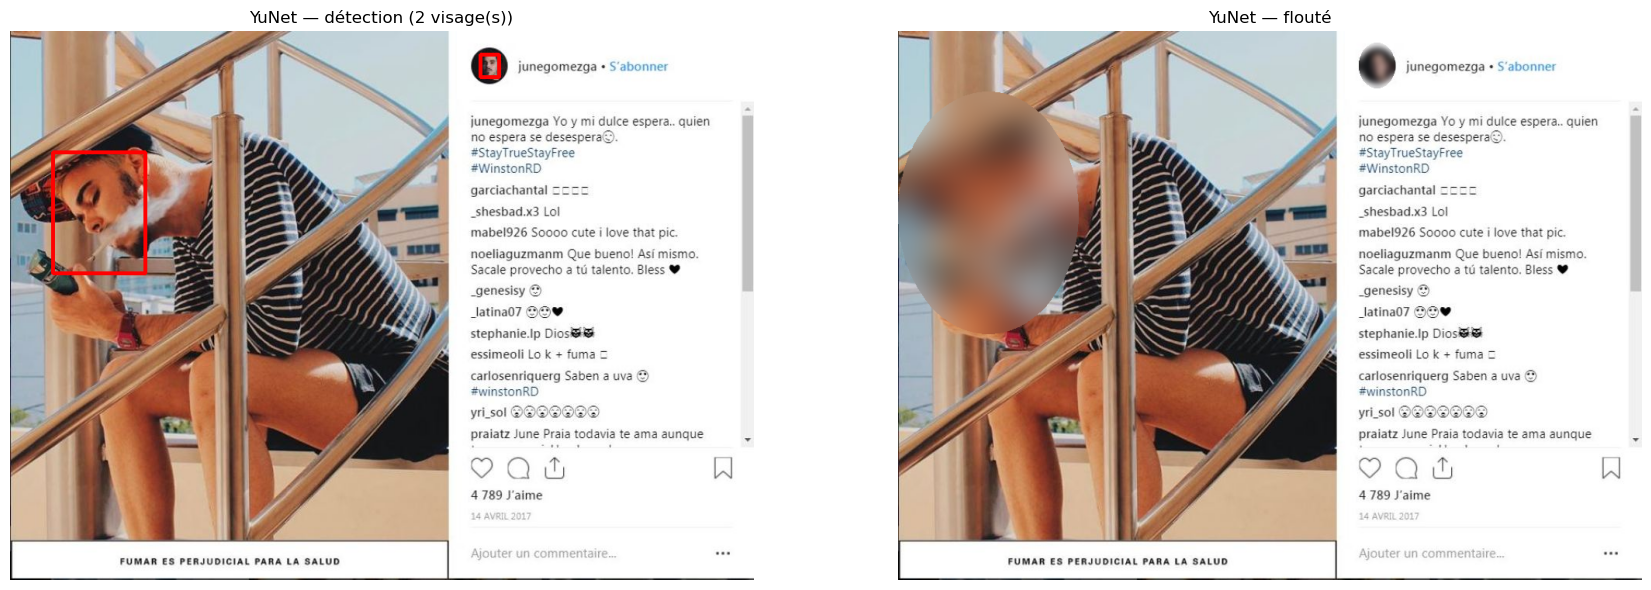

**Figure 1** : YuNet — visages détectés (gauche) et floutés (droite).

In [42]:
# Pick one image: detection (left) and blurred faces (right) with YuNet.
sample_path = image_paths[14]
print("Image de test:", sample_path.name)

# Original image (BGR -> RGB for matplotlib display).
original = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)

# YuNet returns the blurred image + the detected boxes.
# Increase blur_factor for a stronger blur (default is 3.0).
img_yn, boxes_yn = bu.blur_faces_yunet(sample_path, blur_factor=10, mask_scale=2,score_threshold=0.4)

# Blurred image: BGR -> RGB for display.
img_yn = cv2.cvtColor(img_yn, cv2.COLOR_BGR2RGB)

def draw_boxes(img_rgb, boxes, color=(255, 0, 0)):
    """Return a copy of the image with a rectangle drawn on each face box."""
    out = img_rgb.copy()
    h, w = out.shape[:2]
    thickness = max(2, int(round(min(h, w) / 200)))  # scale with image size
    for box in boxes:
        x1, y1, x2, y2 = [int(v) for v in box[:4]]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
    return out

img_yn_boxes = draw_boxes(original, boxes_yn)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, im, title in zip(
    axes,
    [img_yn_boxes, img_yn],
    [f"YuNet — détection ({len(boxes_yn)} visage(s))", "YuNet — flouté"],
):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
display(Markdown("**Figure 1** : YuNet — visages détectés (gauche) et floutés (droite)."))

# Floutage par lots et sauvegarde

Les images floutées sont sauvegardées dans `results/blurred_images/<méthode>/`,
en conservant les noms de fichiers d'origine. Ce dossier de résultats est ignoré
par git (sorties régénérables).

In [43]:
# Output folder and detectors to run.
output_root = project_root / "results/blurred_images"
methods = ["yunet"]

# Blur the selected images with each method and save them.
summaries = {}
for method in methods:
    out_dir = output_root / method
    print(f"\n=== {method} ===")
    summaries[method] = bu.blur_image_paths(
        image_paths,
        out_dir,
        method=method,
        score_threshold=0.4,
        blur_factor=10,    # intensité du flou (défaut 3.0) — plus grand = plus flou
        mask_scale=2,    # taille de la zone floutée autour du visage (défaut 1.3)
        ellipse=True,      # True = flou en ellipse ; False = tout le rectangle
    )


=== yunet ===
[yunet] 6.jpg: 11 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\6.jpg
[yunet] 8.jpg: 10 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\8.jpg
[yunet] 9.jpg: 2 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\9.jpg
[yunet] 11.jpg: 1 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\11.jpg
[yunet] 20.jpg: 1 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\20.jpg
[yunet] 22.PNG: 2 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\22.PNG
[yunet] 23.PNG: 9 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\23.PNG
[yunet] 24.png: 2 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\24.png
[yunet] 25.png: 3 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\25.png
[yunet] 26.png: 1 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\26.png
[yunet] 27.png: 6 face(s) -> C:\TEMP\projects\omata\results\blurred_images\yunet\27.png
[yunet] 28.png: 2 fac

## Résumé

Nombre de visages détectés et floutés.

In [24]:
# Per-method summary: number of images and detected faces.
rows = []
for method, summary in summaries.items():
    n_images = len(summary)
    n_faces = sum(s["n_faces"] for s in summary)
    n_with_face = sum(1 for s in summary if s["n_faces"] > 0)
    rows.append({
        "method": method,
        "n_images": n_images,
        "n_images_with_face": n_with_face,
        "n_faces_total": n_faces,
    })

df_summary = pd.DataFrame(rows)
display(df_summary)
display(Markdown("**Tableau 1** : Nombre de visages détectés et floutés par méthode."))

,method,n_images,n_images_with_face,n_faces_total
0,yunet,17,17,44


**Tableau 1** : Nombre de visages détectés et floutés par méthode.

## Aperçu de toutes les images floutées

La Figure 2 présente l'ensemble des images floutées, 3 par ligne. Elle lit les
fichiers sauvegardés dans `results/blurred_images/yunet/` : exécuter d'abord la
cellule de floutage par lots ci-dessus.

In [ ]:
# Grid of all the blurred images (YuNet), 3 per row.
blurred_dir = output_root / "yunet"
blurred_paths = [blurred_dir / p.name for p in image_paths]

cols = 3
n = len(blurred_paths)
rows = (n + cols - 1) // cols          # number of rows, rounded up

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()                  # turn the 2D grid into a flat list

# Fill one cell per blurred image.
for ax, path in zip(axes, blurred_paths):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(path.name, fontsize=9)
    ax.axis("off")

# Hide the leftover empty cells (when the count isn't a multiple of 3).
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
display(Markdown("**Figure 2** : Toutes les images floutées (YuNet)."))